# What drives evenness? — per-step exploratory analysis

Assembles one row per step containing the **evenness score (target)** plus candidate **predictors**,
then shows which predictors actually relate to evenness. Predictors come in two families:

* **GIS / material** at the step's location — combined surface class (sidewalk+land cover+open space),
  the sidewalk MATERIAL code, the land-cover type, and an in-park flag.
* **Route kinematics** from the GPX — walking speed, slope (grade, from elevation), turning
  (heading change), and elevation.

This is deliberately *exploratory*: it does not commit to a model yet. The correlations and the
grouped feature-importance tell us what a prediction should be based on, and how much of evenness is
even explainable from these variables. Everything is evaluated **grouped by walk** so within-walk
correlation doesn't inflate the result.

> **Note:** `cum_dist` and `elevation` are excluded. On a grouped-by-walk test they act as *route fingerprints* (each walk has its own distance/elevation range), letting a model memorise which walk a step came from rather than learn what makes a step even — which inflates in-sample importance and hurts generalisation. Predictors here are surface/material (GIS) and gait kinematics only.

In [1]:
import os, glob, json, numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime
from scipy.signal import find_peaks
from scipy.stats import norm, spearmanr, f_oneway

# ---- paths (auto-detected for your layout: data + gis + GPS live at the repo root) ----
REPO_ROOT = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(REPO_ROOT, 'Individual Users')): break
    _up = os.path.dirname(REPO_ROOT)
    if _up == REPO_ROOT: break
    REPO_ROOT = _up
print('REPO_ROOT =', REPO_ROOT)
WALKS_DIR   = os.path.join(REPO_ROOT, 'GPS')
SIDEWALK    = os.path.join(REPO_ROOT, 'gis', 'sidewalk_inventory.geojson')
OPENSPACE   = os.path.join(REPO_ROOT, 'gis', 'open_space.geojson')
LANDCOVER   = os.path.join(REPO_ROOT, 'gis')          # folder; auto-finds LCLU_*.shp inside
SCALER_JSON = os.path.join(REPO_ROOT, 'Charts_Graphs', 'evenness_scaler.json')  # optional
CHARTS_DIR  = os.path.join(REPO_ROOT, 'Charts_Graphs'); os.makedirs(CHARTS_DIR, exist_ok=True)

# ---- signal / layout ----
FS = 62.5; MIN_DP, MAX_DP = 15, 150
ALL_SENSORS = [f'pressure_{i:02d}' for i in range(1, 13)]
WITHIN_STEP  = ['orient_range_a','orient_range_b','cop_wander','press_jitter','gyro_std']
STEP_TO_STEP = ['stance_dur','loading_rate','impact','tiltA','tiltB']
EVENNESS_FEATURES = WITHIN_STEP + [f'{c}_roll3_std' for c in STEP_TO_STEP]
METRIC = 'EPSG:26986'; SW_TOL, LC_TOL, OS_TOL = 15.0, 1.5, 8.0
print('config ready')

REPO_ROOT = c:\Users\Sam\WalkSensePlace
config ready


## 1. Evenness scoring (per step, with timestamp)

The label-free extractor + robust scaler from the evenness notebook. Loads the saved `evenness_scaler.json` if present, otherwise fits on the walks being analysed.

In [2]:
def find_steps(tot):
    mx = np.nanmax(tot) if np.nanmax(tot) > 0 else 1.0
    pk, _ = find_peaks(tot, distance=25, prominence=mx*0.15); return pk

def extract_steps(df, rec, foot):
    df = df.reset_index(drop=True)
    if len(df) < MIN_DP: return pd.DataFrame()
    P = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).values; tot = P.sum(1)
    ax = pd.to_numeric(df['accel_x'],errors='coerce').fillna(0).values
    ay = pd.to_numeric(df['accel_y'],errors='coerce').fillna(0).values
    az = pd.to_numeric(df['accel_z'],errors='coerce').fillna(0).values
    G = df[['gyro_x','gyro_y','gyro_z']].apply(pd.to_numeric,errors='coerce').fillna(0).values; Gc = G-np.median(G,0)
    amag = np.sqrt(ax**2+ay**2+az**2); gmag = np.sqrt((Gc**2).sum(1))
    tA = np.degrees(np.arctan2(ax, np.hypot(ay,az))); tB = np.degrees(np.arctan2(az, np.hypot(ax,ay)))
    ts = pd.to_numeric(df['timestamp'],errors='coerce').values if 'timestamp' in df.columns else np.arange(len(df))
    pk = find_steps(tot); rows=[]; o=0
    for i in range(len(pk)-1):
        a,b = pk[i],pk[i+1]; n=b-a
        if n<MIN_DP or n>MAX_DP: continue
        Pw=P[a:b]; totw=tot[a:b]; sc=totw.mean()+1e-9; wam=amag[a:b]; wgm=gmag[a:b]
        Qn=Pw/(Pw.sum(1,keepdims=True)+1e-9); t=int(np.argmin(wgm))
        rows.append(dict(rec=rec,foot=foot,order=o,t_ms=float(ts[(a+b)//2]),
            orient_range_a=float(tA[a:b].max()-tA[a:b].min()), orient_range_b=float(tB[a:b].max()-tB[a:b].min()),
            cop_wander=float(np.mean(np.abs(np.diff(Qn,axis=0)).sum(1))) if n>1 else 0.,
            press_jitter=float(np.mean(np.std(np.diff(Pw,n=2,axis=0),axis=0))/sc) if n>2 else 0.,
            gyro_std=float(np.mean([np.std(Gc[a:b,k]) for k in range(3)])),
            stance_dur=float((totw>0.5*sc).mean()), loading_rate=float(np.max(np.diff(totw))/sc),
            impact=float(wam[:max(1,n//3)].max()/(np.median(wam)+1e-9)), tiltA=float(tA[a:b][t]), tiltB=float(tB[a:b][t]))); o+=1
    return pd.DataFrame(rows)

def steps_with_roll(recording_csv):
    raw = pd.read_csv(recording_csv, low_memory=False)
    if 'sole_id' not in raw.columns: return pd.DataFrame()
    parts=[]
    for s in raw['sole_id'].dropna().unique():
        foot = 'right' if str(s) in ('1','1.0') else 'left' if str(s) in ('2','2.0') else f'sole{s}'
        st = extract_steps(raw[raw['sole_id']==s], os.path.basename(recording_csv), foot)
        if len(st): parts.append(st)
    if not parts: return pd.DataFrame()
    S = pd.concat(parts, ignore_index=True).sort_values(['foot','order'])
    for c in STEP_TO_STEP:
        S[f'{c}_roll3_std'] = S.groupby('foot')[c].transform(lambda x: x.rolling(3,min_periods=1).std().fillna(0))
    return S

def robust_cs(x):
    m=float(np.median(x)); s=float(np.subtract(*np.percentile(x,[75,25])))
    return m,(s if s>0 else (float(np.std(x)) or 1.0))

def fit_scaler(df):
    cs={c:robust_cs(df[c].values) for c in EVENNESS_FEATURES}
    Z=np.column_stack([np.clip((df[c].values-cs[c][0])/(cs[c][1]+1e-9),-4,4) for c in EVENNESS_FEATURES])
    U=Z.mean(1); um,us=robust_cs(U)
    return {'features':EVENNESS_FEATURES,'feat_center_scale':cs,'U_center':um,'U_scale':us}

def apply_scaler(df, sc):
    cs=sc['feat_center_scale']
    Z=np.column_stack([np.clip((df[c].values-cs[c][0])/(cs[c][1]+1e-9),-4,4) for c in sc['features']])
    U=Z.mean(1); return np.clip(100*norm.cdf(-(U-sc['U_center'])/(sc['U_scale']+1e-9)),0,100)
print('evenness scoring defined')

evenness scoring defined


## 2. GPX kinematics

Per GPS point: walking speed, slope/grade (from elevation), turn angle (heading change), elevation, and distance along the route.

In [3]:
def gpx_kinematics(path):
    root=ET.parse(path).getroot(); strip=lambda t:t.split('}')[-1]; P=[]
    for pt in root.iter():
        if strip(pt.tag)!='trkpt': continue
        lat=float(pt.attrib['lat']); lon=float(pt.attrib['lon']); ele=np.nan; t=None
        for c in pt:
            if strip(c.tag)=='ele':
                try: ele=float(c.text)
                except: pass
            if strip(c.tag)=='time': t=datetime.fromisoformat((c.text or '').strip().replace('Z','+00:00'))
        if t is None: continue
        P.append((lon,lat,ele,int(t.timestamp()*1000)))
    if len(P)<3: return pd.DataFrame()
    lon=np.array([p[0] for p in P]); lat=np.array([p[1] for p in P]); ele=np.array([p[2] for p in P]); tms=np.array([p[3] for p in P],float)
    x=(lon-lon.mean())*np.cos(np.radians(lat.mean()))*111320.0; y=(lat-lat.mean())*110540.0
    dx=np.diff(x,prepend=x[0]); dy=np.diff(y,prepend=y[0]); dist=np.hypot(dx,dy)
    dt=np.diff(tms,prepend=tms[0]-1000)/1000.0; dt[dt<=0]=np.nan
    speed=np.clip(dist/dt,0,6)
    dele=np.diff(ele,prepend=ele[0]); grade=np.where(dist>0.3,dele/dist,0.0)
    head=np.degrees(np.arctan2(dy,dx)); dhead=np.abs((np.diff(head,prepend=head[0])+180)%360-180)
    return pd.DataFrame(dict(lon=lon,lat=lat,ele=ele,tms=tms,
        speed=speed, grade=grade, abs_turn=dhead, cum_dist=np.cumsum(dist)))
print('kinematics defined')

kinematics defined


## 3. GIS per-point (sidewalk + land cover + open space)

The v7 three-layer classification, returning surface class, sidewalk material, land-cover type, and an in-park flag for each GPS point.

In [4]:
import geopandas as gpd
from shapely.geometry import Point, shape
from shapely.strtree import STRtree
SW_CODES={'cc':'paved','bc':'paved','gb':'paved','br':'paved','cb':'paved','bl':'paved','ot':'unknown'}
SW_FIELDS=['MATERIAL','material','Material']; LC_FIELDS=['COVERNAME','COVERTYPE','LC_DESC','LANDCOVER','LU_DESC']
def sw_class(v):
    s=str(v).strip().lower()
    return SW_CODES.get(s,'paved' if any(k in s for k in['concret','asphalt','brick','granit','stone','cement','bitum']) else 'unknown')
def lc_class(v):
    s=str(v).strip().lower()
    if any(k in s for k in['open space','grass','pasture','cultivat','recreation','golf','lawn','cemeter']): return 'grass'
    if any(k in s for k in['impervious','pavement','road','building','commercial','industrial','residential']): return 'paved'
    if any(k in s for k in['bare','soil','sand','barren']): return 'loose'
    return 'unknown'
def read_layer(path):
    if not path or not os.path.exists(path): return None
    g=gpd.read_file(path)
    if g.crs is None: g=g.set_crs('EPSG:4326')
    return g.to_crs(METRIC)
def load_gis():
    sw=read_layer(SIDEWALK); osp=read_layer(OPENSPACE)
    if LANDCOVER and os.path.isdir(LANDCOVER):
        import glob as _g; tiles=[read_layer(t) for t in _g.glob(os.path.join(LANDCOVER,'**','LCLU_*.shp'),recursive=True)]
        lc=pd.concat([t for t in tiles if t is not None]) if any(t is not None for t in tiles) else None
        if lc is not None: lc=gpd.GeoDataFrame(lc,geometry='geometry',crs=METRIC)
    else: lc=read_layer(LANDCOVER)
    swf=next((c for c in SW_FIELDS if sw is not None and c in sw.columns),None)
    lcf=next((c for c in LC_FIELDS if lc is not None and c in lc.columns),None)
    def tree(gdf): 
        geoms=[g for g in gdf.geometry.values if g is not None and not g.is_empty] if gdf is not None else []
        return (STRtree(geoms) if geoms else None), geoms
    swt,swg=tree(sw); lct,lcg=tree(lc); ost,osg=tree(osp)
    swc=[sw_class(v) for v in sw[swf]] if swf else []; swm=[str(v) for v in sw[swf]] if swf else []
    lcc=[lc_class(v) for v in lc[lcf]] if lcf else []; lcn=[str(v) for v in lc[lcf]] if lcf else []
    return dict(swt=swt,swg=swg,swc=swc,swm=swm, lct=lct,lcg=lcg,lcc=lcc,lcn=lcn, ost=ost,osg=osg)
def classify_points(lon, lat, G):
    Pm=gpd.GeoSeries([Point(a,b) for a,b in zip(lon,lat)],crs='EPSG:4326').to_crs(METRIC)
    cls=[]; mat=[]; lcn=[]; opn=[]
    for pt in Pm:
        c,m,l,o='unknown','none','none',0
        if G['swt'] is not None:
            i=G['swt'].nearest(pt)
            if G['swg'][i].distance(pt)<=SW_TOL and G['swc'][i]!='unknown': c,m=G['swc'][i],G['swm'][i]
        if G['lct'] is not None:
            i=G['lct'].nearest(pt)
            if G['lcg'][i].distance(pt)<=LC_TOL:
                l=G['lcn'][i]
                if c=='unknown' and G['lcc'][i] in('paved','grass','loose'): c=G['lcc'][i]
        if G['ost'] is not None:
            i=G['ost'].nearest(pt)
            if G['osg'][i].distance(pt)<=OS_TOL:
                o=1
                if c=='unknown': c='grass'
        cls.append(c); mat.append(m); lcn.append(l); opn.append(o)
    return cls,mat,lcn,opn
print('GIS classify defined')

GIS classify defined


## 4. Assemble the per-step table

For each walk: score evenness per step, derive kinematics per GPS point, classify each point via GIS, then time-match each step to its nearest GPS point and record predictors + target.

In [5]:
def paired_recording(gpx_pts_tms, walks_dir):
    if len(gpx_pts_tms)==0: return None
    g0,g1=gpx_pts_tms.min(),gpx_pts_tms.max(); best,ov=None,0
    for f in glob.glob(os.path.join(walks_dir,'*.csv')):
        try: ts=pd.to_numeric(pd.read_csv(f,usecols=['timestamp'])['timestamp'],errors='coerce').dropna()
        except: continue
        if not len(ts): continue
        o=max(0,min(g1,int(ts.max()))-max(g0,int(ts.min())))
        if o>ov: ov,best=o,f
    return best

G = load_gis()
SCALER = json.load(open(SCALER_JSON)) if os.path.exists(SCALER_JSON) else None
gpx_files = sorted(glob.glob(os.path.join(WALKS_DIR,'*.gpx')))
print(f'cwd = {os.getcwd()}')
print(f'WALKS_DIR = {os.path.abspath(WALKS_DIR)!r}  ->  {len(gpx_files)} GPX file(s)')
print(f'scaler = {"loaded from " + SCALER_JSON if SCALER else "will fit on walks"}')
if not gpx_files:
    raise FileNotFoundError(
        f"No .gpx under WALKS_DIR={os.path.abspath(WALKS_DIR)!r}. Set WALKS_DIR in the config cell "
        r"to your walks folder, e.g. r'C:\Users\Sam\WalkSensePlace\GPS'.")

rows=[]; drops=[]
for gpx in gpx_files:
    name=os.path.basename(gpx)
    kin = gpx_kinematics(gpx)
    if not len(kin): drops.append(f'{name}: 0 usable GPS points (need <time> on trkpts)'); continue
    rec = paired_recording(kin['tms'].values, WALKS_DIR)
    if not rec:
        cand = gpx.replace('.gpx','_GPS.csv')
        rec = cand if os.path.exists(cand) else None
    if not rec: drops.append(f'{name}: no insole CSV overlaps its time range'); continue
    steps = steps_with_roll(rec)
    if not len(steps): drops.append(f'{name}: 0 steps from {os.path.basename(rec)}'); continue
    if SCALER is None: SCALER = fit_scaler(steps)     # fit on first walk if no saved scaler
    steps['evenness'] = apply_scaler(steps, SCALER)
    cls,mat,lcn,opn = classify_points(kin['lon'].values, kin['lat'].values, G)
    kin=kin.assign(gis_class=cls, sidewalk_material=mat, landcover=lcn, in_openspace=opn)
    # time-match each step to nearest GPS point
    kt=kin['tms'].values; order=np.argsort(kt)
    for _,s in steps.iterrows():
        j=order[np.searchsorted(kt[order], s['t_ms'])-1] if s['t_ms']>=kt[order][0] else order[0]
        p=kin.iloc[j]
        rows.append(dict(walk=os.path.basename(gpx), evenness=s['evenness'],
            gis_class=p['gis_class'], sidewalk_material=p['sidewalk_material'],
            landcover=p['landcover'], in_openspace=p['in_openspace'],
            speed=p['speed'], grade=p['grade'], abs_turn=p['abs_turn']))
if not rows:
    msg = '\n  '.join(drops) if drops else '(no GPX processed)'
    raise ValueError(f'No steps assembled from {len(gpx_files)} GPX. Per-walk reasons:\n  {msg}')
DATA = pd.DataFrame(rows)
DATA.to_csv(os.path.join(CHARTS_DIR,'evenness_drivers_table.csv'), index=False)
print(f'{len(DATA)} steps assembled across {DATA.walk.nunique()} walk(s) -> evenness_drivers_table.csv')
if drops: print('dropped walks:\n  ' + '\n  '.join(drops))
print(DATA.head())

cwd = c:\Users\Sam\WalkSensePlace\notebooks
WALKS_DIR = 'c:\\Users\\Sam\\WalkSensePlace\\GPS'  ->  10 GPX file(s)
scaler = loaded from c:\Users\Sam\WalkSensePlace\Charts_Graphs\evenness_scaler.json
4527 steps assembled across 10 walk(s) -> evenness_drivers_table.csv
                      walk   evenness gis_class sidewalk_material  \
0  REC_20260424_190906.gpx  96.560954     grass              none   
1  REC_20260424_190906.gpx  84.364540     grass              none   
2  REC_20260424_190906.gpx  51.777713     grass              none   
3  REC_20260424_190906.gpx  81.691733     grass              none   
4  REC_20260424_190906.gpx  62.654539     grass              none   

              landcover  in_openspace     speed  grade    abs_turn  
0  Developed Open Space             0  0.129898    0.0  164.282338  
1  Developed Open Space             0  0.795807    0.0   82.281673  
2  Developed Open Space             0  0.669987    0.0   80.009269  
3  Developed Open Space             0  1.1

## 5. What relates to evenness?

Numeric predictors: Spearman correlation with evenness (rank-based, robust). Categorical predictors: mean evenness per category with an ANOVA F (bigger = separates more).

Numeric predictors — Spearman correlation with evenness:
  speed      rho = +0.115
  grade      rho = +0.015
  abs_turn   rho = -0.015

Categorical predictors — mean evenness by category (ANOVA F):
  gis_class (F=13.7):
     {'grass': 38.0, 'loose': 52.4, 'paved': 42.3, 'unknown': 27.9}
  sidewalk_material (F=30.5):
     {'BR': 45.9, 'CB': 27.3, 'CC': 41.1, 'none': 37.8}
  landcover (F=5.2):
     {'Bare Land': 45.4, 'Deciduous Forest': 39.0, 'Developed Open Space': 41.7, 'Impervious': 43.0, 'Scrub/Shrub': 40.9, 'Water': 37.0}
  in_openspace (F=55.3):
     {0: 44.6, 1: 39.6}


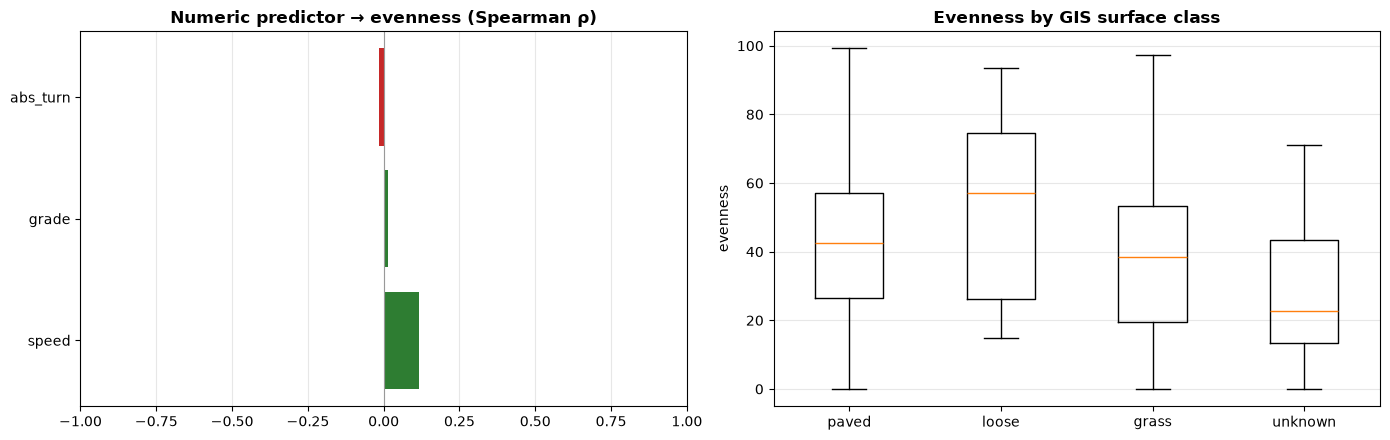

In [6]:
NUM = ['speed','grade','abs_turn']   # dropped cum_dist & elevation (route fingerprints, not drivers)
CAT = ['gis_class','sidewalk_material','landcover','in_openspace']
print('Numeric predictors — Spearman correlation with evenness:')
corr = {c: spearmanr(DATA[c], DATA['evenness'], nan_policy='omit').statistic for c in NUM}
for k,v in sorted(corr.items(), key=lambda kv:-abs(kv[1])): print(f'  {k:10s} rho = {v:+.3f}')
print('\nCategorical predictors — mean evenness by category (ANOVA F):')
for c in CAT:
    groups=[DATA.loc[DATA[c]==g,'evenness'].values for g in DATA[c].dropna().unique() if (DATA[c]==g).sum()>=5]
    F=f_oneway(*groups).statistic if len(groups)>1 else np.nan
    print(f'  {c} (F={F:.1f}):')
    print('    ', DATA.groupby(c)['evenness'].mean().round(1).to_dict())

fig,ax=plt.subplots(1,2,figsize=(14,4.5))
cv=pd.Series(corr).reindex(pd.Series(corr).abs().sort_values(ascending=False).index)
ax[0].barh(range(len(cv)), cv.values, color=['#2E7D32' if v>0 else '#C62828' for v in cv.values])
ax[0].set_yticks(range(len(cv))); ax[0].set_yticklabels(cv.index); ax[0].axvline(0,color='#999',lw=.8)
ax[0].set_title('Numeric predictor → evenness (Spearman ρ)',fontweight='bold'); ax[0].set_xlim(-1,1); ax[0].grid(axis='x',alpha=.3)
order=[g for g in['paved','loose','grass','unknown'] if g in DATA['gis_class'].unique()]
ax[1].boxplot([DATA.loc[DATA.gis_class==g,'evenness'].values for g in order], tick_labels=order, showfliers=False)
ax[1].set_title('Evenness by GIS surface class',fontweight='bold'); ax[1].set_ylabel('evenness'); ax[1].grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'evenness_drivers_explore.png'),dpi=140,bbox_inches='tight'); plt.show()

## 6. How predictable is evenness? (grouped regression)

A gradient-boosted regressor predicts evenness from all predictors, scored with **GroupKFold by walk** (so it must generalise to unseen walks), with permutation importance to rank the predictors.

Grouped-by-walk CV R^2 = -0.199  (share of per-step evenness variance explained by GIS+material+kinematics)

Top predictors (permutation importance):
speed                             0.1453
abs_turn                          0.1141
in_openspace_0.0                  0.0816
gis_class_grass                   0.0181
grade                             0.0131
sidewalk_material_CB              0.0117
landcover_Developed Open Space    0.0105
sidewalk_material_BR              0.0078
landcover_Deciduous Forest        0.0069
landcover_Impervious              0.0066
sidewalk_material_CC              0.0061
sidewalk_material_none            0.0059
gis_class_unknown                 0.0045
landcover_Scrub/Shrub             0.0023
gis_class_paved                   0.0019


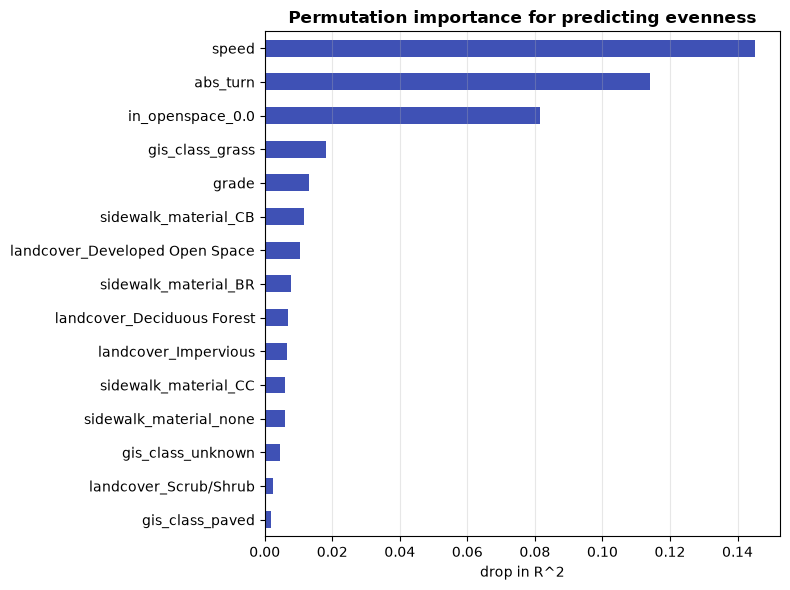

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

X = pd.get_dummies(DATA[NUM+CAT], columns=CAT, dummy_na=True).fillna(0)
y = DATA['evenness'].values; groups = DATA['walk'].values
nsplit = min(5, DATA['walk'].nunique())
if nsplit < 2:
    print('Need >=2 walks for grouped CV — add more walks.')
else:
    gkf=GroupKFold(n_splits=nsplit)
    model=HistGradientBoostingRegressor(max_depth=4, learning_rate=0.06, max_iter=300, random_state=42)
    pred=cross_val_predict(model, X, y, cv=gkf, groups=groups)
    r2=r2_score(y,pred)
    print(f'Grouped-by-walk CV R^2 = {r2:.3f}  (share of per-step evenness variance explained by GIS+material+kinematics)')
    model.fit(X,y)
    imp=permutation_importance(model,X,y,n_repeats=8,random_state=42,scoring='r2')
    IM=pd.Series(imp.importances_mean,index=X.columns).sort_values(ascending=False).head(15)
    print('\nTop predictors (permutation importance):'); print(IM.round(4).to_string())
    fig,ax=plt.subplots(figsize=(8,6)); IM[::-1].plot.barh(ax=ax,color='#3F51B5')
    ax.set_title('Permutation importance for predicting evenness',fontweight='bold'); ax.set_xlabel('drop in R^2'); ax.grid(axis='x',alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'evenness_drivers_importance.png'),dpi=140,bbox_inches='tight'); plt.show()

## 7. Reading the result

* **CV R²** says how much per-step evenness these variables explain for an *unseen* walk. A low value
  (near 0) means evenness is mostly not predictable from GIS/material/kinematics — likely, because
  evenness is a compliance signal the sensor reads directly, while GIS material only knows paved-vs-green.
* **Importance ranking** says *what* carries the signal. Expect `gis_class`/land-cover (the grass vs
  firm split) and possibly `speed`/`abs_turn`/`grade` to lead; sidewalk MATERIAL detail (concrete vs
  brick) will likely be weak, mirroring the paved≈loose overlap.
* This is the evidence for choosing a prediction target: if only the grass/firm split is predictable,
  a sensible model predicts a coarse evenness *band* from surface + kinematics, not a precise score.